In [1]:
import numpy as np
import pandas as pd
import pickle
from os import path

# Libraries for data normalization
from sklearn import preprocessing
from sklearn.preprocessing import (StandardScaler, OrdinalEncoder, LabelEncoder,
                                    MinMaxScaler, OneHotEncoder, Normalizer,
                                    MaxAbsScaler, RobustScaler, PowerTransformer)

# Libraries for plotting
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import metrics
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

# Libraries for RandomForest and hyperparameter optimization
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

import itertools
from itertools import cycle

---------
## Dataset and Preprocessing


In [2]:
!pip install kaggle
!kaggle datasets download hassan06/nslkdd

Dataset URL: https://www.kaggle.com/datasets/hassan06/nslkdd
License(s): unknown
 72% 10.0M/13.9M [00:00<00:00, 42.9MB/s]
100% 13.9M/13.9M [00:00<00:00, 42.0MB/s]


In [3]:
!unzip nslkdd

Archive:  nslkdd.zip
  inflating: KDDTest+.arff           
  inflating: KDDTest+.txt            
  inflating: KDDTest-21.arff         
  inflating: KDDTest-21.txt          
  inflating: KDDTest1.jpg            
  inflating: KDDTrain+.arff          
  inflating: KDDTrain+.txt           
  inflating: KDDTrain+_20Percent.arff  
  inflating: KDDTrain+_20Percent.txt  
  inflating: KDDTrain1.jpg           
  inflating: index.html              
  inflating: nsl-kdd/KDDTest+.arff   
  inflating: nsl-kdd/KDDTest+.txt    
  inflating: nsl-kdd/KDDTest-21.arff  
  inflating: nsl-kdd/KDDTest-21.txt  
  inflating: nsl-kdd/KDDTest1.jpg    
  inflating: nsl-kdd/KDDTrain+.arff  
  inflating: nsl-kdd/KDDTrain+.txt   
  inflating: nsl-kdd/KDDTrain+_20Percent.arff  
  inflating: nsl-kdd/KDDTrain+_20Percent.txt  
  inflating: nsl-kdd/KDDTrain1.jpg   
  inflating: nsl-kdd/index.html      


In [5]:
# Column names
feature = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent","hot",
           "num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
           "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login",
           "is_guest_login","count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
           "same_srv_rate","diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
           "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
           "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
           "dst_host_rerror_rate","dst_host_srv_rerror_rate","label","difficulty"]

# File paths
train_path = './KDDTrain+.txt'
test_path = './KDDTest+.txt'
test21_path = './KDDTest-21.txt'

# Load the training data
train_data = pd.read_csv(train_path, names=feature)
print("First 5 observations:")
print(train_data.head())

First 5 observations:
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.60                         

In [6]:
# Removing the 'difficulty' column
train_data.drop(['difficulty'], axis=1, inplace=True)
print("New shape:", train_data.shape)
train_data.info()
print(train_data.describe().T)

New shape: (125973, 42)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 42 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     125973 non-null  int64  
 1   protocol_type                125973 non-null  object 
 2   service                      125973 non-null  object 
 3   flag                         125973 non-null  object 
 4   src_bytes                    125973 non-null  int64  
 5   dst_bytes                    125973 non-null  int64  
 6   land                         125973 non-null  int64  
 7   wrong_fragment               125973 non-null  int64  
 8   urgent                       125973 non-null  int64  
 9   hot                          125973 non-null  int64  
 10  num_failed_logins            125973 non-null  int64  
 11  logged_in                    125973 non-null  int64  
 12  num_compromised              12597

In [7]:
# Distribution of attack labels
print("Attack Labels Distribution:")
print(train_data['label'].value_counts())

Attack Labels Distribution:
label
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64


In [8]:
# Function that converts attack labels to the desired classes
def change_label(df):
    df.label.replace(['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'],
                     'Dos', inplace=True)
    df.label.replace(['ftp_write','guess_passwd','httptunnel','imap','multihop','named','phf','sendmail',
                      'snmpgetattack','snmpguess','spy','warezclient','warezmaster','xlock','xsnoop'],
                     'R2L', inplace=True)
    df.label.replace(['ipsweep','mscan','nmap','portsweep','saint','satan'],
                     'Probe', inplace=True)
    df.label.replace(['buffer_overflow','loadmodule','perl','ps','rootkit','sqlattack','xterm'],
                     'U2R', inplace=True)

change_label(train_data)
print("After Updating Labels:")
print(train_data['label'].value_counts())

After Updating Labels:
label
normal    67343
Dos       45927
Probe     11656
R2L         995
U2R          52
Name: count, dtype: int64


<ipython-input-8-864918329c5d>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.label.replace(['apache2','back','land','neptune','mailbomb','pod','processtable','smurf','teardrop','udpstorm','worm'],


In [9]:
# Creating a copy of the data with multi-class labels
multi_data = train_data.copy()
multi_label = pd.DataFrame(multi_data['label'])

In [10]:
# Using StandardScaler to normalize numerical columns
std_scaler = StandardScaler()
def standardization(df, cols):
    for col in cols:
        arr = df[col].values
        df[col] = std_scaler.fit_transform(arr.reshape(-1, 1))
    return df

numeric_col = multi_data.select_dtypes(include='number').columns
data = standardization(multi_data, numeric_col)

In [11]:
# Converting labels to numerical (in the form 0,1,2,3,4: e.g. Dos, normal, Probe, R2L, U2R)
le2 = LabelEncoder()
multi_data['intrusion'] = le2.fit_transform(multi_data['label'])
print("Encoded 'intrusion' distribution:")
print(pd.Series(multi_data['intrusion']).value_counts())

Encoded 'intrusion' distribution:
intrusion
4    67343
0    45927
1    11656
2      995
3       52
Name: count, dtype: int64


In [12]:
# Removing the original 'label' column
multi_data.drop(labels=['label'], axis=1, inplace=True)

# One-hot encoding of categorical columns (protocol_type, service, flag)
multi_data = pd.get_dummies(multi_data, columns=['protocol_type','service','flag'], prefix="", prefix_sep="")

# Separating feature and label variables
X_data = multi_data.drop(labels=['intrusion'], axis=1)
y_data = multi_data['intrusion']

print('X_data shape:', X_data.shape, '\ny_data shape:', y_data.shape)

X_data shape: (125973, 122) 
y_data shape: (125973,)


-----
## Splitting Training and Test Data

In [13]:
# Dividing the data as 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.20, random_state=42)
print("Training data shape:", X_train.shape)
print("Test data shape:", X_test.shape)

Training data shape: (100778, 122)
Test data shape: (25195, 122)


------
## RandomForest Model with Hyperparameter Optimization

In [14]:
# Hyperparameter ranges for RandomForest
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1)

# Hyperparameter optimization with RandomizedSearchCV
random_search = RandomizedSearchCV(estimator=rf_classifier, param_distributions=param_dist,
                                   n_iter=10, cv=3, verbose=1, n_jobs=-1, random_state=42)

# Training the model with training data
random_search_result = random_search.fit(X_train, y_train)
print(f"Best parameters: {random_search_result.best_params_}")

# Getting the best model
best_model = random_search_result.best_estimator_

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best parameters: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'bootstrap': False}


-----
## Model Evaluation and Analysis

Test Accuracy: 99.86108355%
Classification Report:

              precision    recall  f1-score   support

      Normal    0.99978   0.99935   0.99956      9181
         DoS    0.99830   0.99703   0.99767      2357
       Probe    0.99083   0.96429   0.97738       224
         R2L    1.00000   0.27273   0.42857        11
         U2R    0.99799   0.99955   0.99877     13422

    accuracy                        0.99861     25195
   macro avg    0.99738   0.84659   0.88039     25195
weighted avg    0.99861   0.99861   0.99852     25195



<Figure size 1000x800 with 0 Axes>

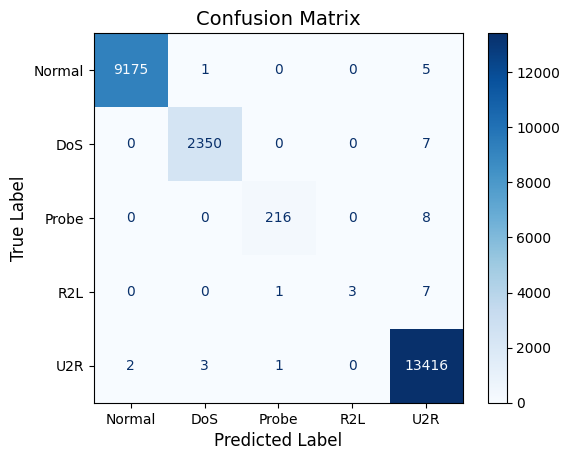

In [15]:
# Evaluating the model on the test data
test_accuracy = best_model.score(X_test, y_test)
print(f'Test Accuracy: {test_accuracy * 100:.8f}%')

# Predictions for test data
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)

# Classification Report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Normal', 'DoS', 'Probe', 'R2L', 'U2R'], digits=5))

# Calculating and visualizing the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'DoS', 'Probe', 'R2L', 'U2R'])
disp.plot(cmap=plt.cm.Blues, values_format="d")
plt.title("Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.show()

------
## Drawing the ROC and AUC Curve

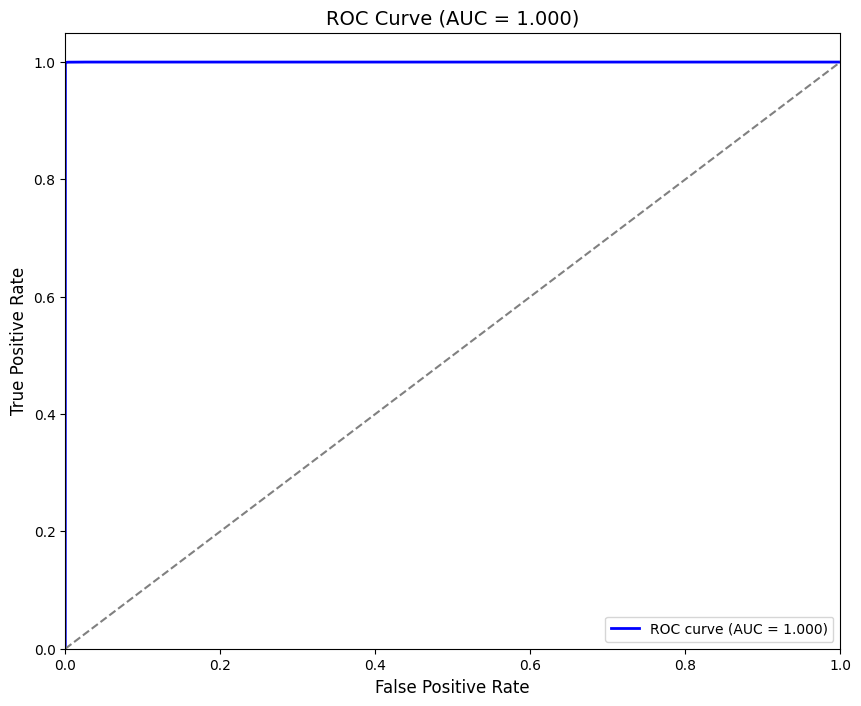

AUC Score: 1.000


In [16]:
# Binarizing test labels for ROC and AUC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # there are 5 classes
# y_pred_proba already gives probabilities for each class

# Multi-class ROC and AUC calculation
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_pred_proba.ravel())
roc_auc = auc(fpr, tpr)

# Drawing the ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label='ROC curve (AUC = {0:0.3f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Random classification line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve (AUC = {:.3f})'.format(roc_auc), fontsize=14)
plt.legend(loc='lower right')
plt.show()

# Calculating Multi-class AUC Score (with ovr strategy)
auc_score = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr')
print(f"AUC Score: {auc_score:.3f}")